In [1]:
# Jupyter inline defaults to bbox_inches="tight" when displaying figures.
# That breaks inset_axes + mark_inset (huge raster). Use inline_bbox_none() only
# around plt.show() for the KDE/inset figure; other cells can use tight_layout normally.
from contextlib import contextmanager

import matplotlib as mpl


@contextmanager
def inline_bbox_none():
    """Temporarily disable tight bbox for Jupyter inline display (inset figures)."""
    from IPython import get_ipython

    ip = get_ipython()
    prev_inline = None
    prev_rc = mpl.rcParams["savefig.bbox"]
    if ip is not None:
        prev_inline = ip.config.get("InlineBackend.print_figure_kwargs")
        ip.run_line_magic(
            "config",
            "InlineBackend.print_figure_kwargs = {'bbox_inches': None}",
        )
    mpl.rcParams["savefig.bbox"] = "standard"
    try:
        yield
    finally:
        mpl.rcParams["savefig.bbox"] = prev_rc
        if ip is not None:
            if prev_inline is None:
                ip.run_line_magic(
                    "config",
                    "InlineBackend.print_figure_kwargs = {}",
                )
            else:
                ip.run_line_magic(
                    "config",
                    f"InlineBackend.print_figure_kwargs = {prev_inline!r}",
                )



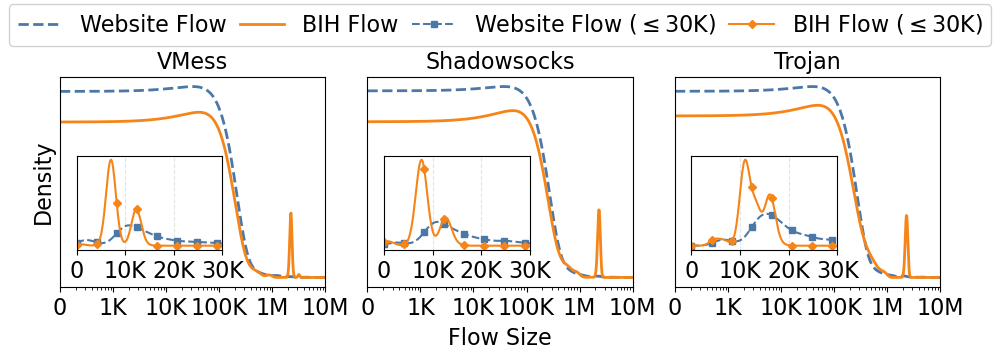

In [19]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.stats import gaussian_kde

STAT_ROOT = "../data_extract"
PROTOCOLS = ["VMess", "Shadowsocks", "Trojan"]
FLOW_SIZE_ROOT = "/data/exp/lxyu/Dataset/WF/VisualSeg/flow_size"

# Canonical main-panel window up to 10⁷ (10M), matching requested tick labels.
# Tick at 10² is labelled "0" (true zero is invalid on a log-scale x-axis).
MAIN_X_TICKS = np.array([1e2, 1e3, 1e4, 1e5, 1e6, 1e7])
MAIN_X_TICK_LABELS = ["0", "1K", "10K", "100K", "1M", "10M"]
N_KDE_SAMPLES_LOG = 600
N_KDE_SAMPLES_LINEAR = 800
INSET_KDE_MAX = 100_000  # samples for inset KDE
INSET_X_DISPLAY_MAX = 30_000  # visible x-range in inset

BIH_HOSTNAMES = [
    "firefox-settings-attachments.cdn.mozilla.net",
    "firefox.settings.services.mozilla.com",
    "content-signature-2.cdn.mozilla.net",
]


def _load_bih_arrays(protocol: str):
    parts = []
    for host in BIH_HOSTNAMES:
        df = pd.read_csv(f"{STAT_ROOT}/{host}.csv")
        col = df[protocol].dropna().to_numpy(dtype=np.float64)
        parts.append(col)
    bih_concat = np.concatenate(parts) if parts else np.array([])
    services_only = pd.read_csv(
        f"{STAT_ROOT}/firefox.settings.services.mozilla.com.csv"
    )
    srv = services_only[protocol].dropna().to_numpy(dtype=np.float64)
    return bih_concat, srv


def safe_kde_plot(ax, samples, x_eval, markevery=None, **plot_kw):
    s = np.asarray(samples, dtype=float)
    s = s[np.isfinite(s)]
    if s.size == 0:
        return None
    if np.unique(np.round(s, 8)).size < 2:
        return None
    try:
        kde = gaussian_kde(s)
        if markevery is not None:
            plot_kw.setdefault("markevery", markevery)
        (line,) = ax.plot(x_eval, kde(x_eval), **plot_kw)
        return line
    except (np.linalg.LinAlgError, ValueError):
        return None


# layout=None: avoid auto layout heuristics conflicting with inset_axes children.
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5), layout=None)
legend_handles = []

for idx, protocol in enumerate(PROTOCOLS):
    website_flow = np.load(f"{FLOW_SIZE_ROOT}/{protocol.lower()}.npz")["flow_size"].astype(np.float64)
    website_flow = website_flow[np.isfinite(website_flow)]

    bih_all, services_flow = _load_bih_arrays(protocol.lower())
    website_main = website_flow[website_flow > 0]
    bih_main = bih_all[bih_all > 0]

    # Always evaluate KDE on the full main-panel x window so curves are not
    # clipped when a protocol's samples start above 1K (e.g. trojan website min ~5K).
    x_vals_log = np.logspace(
        np.log10(MAIN_X_TICKS[0]),
        np.log10(MAIN_X_TICKS[-1]),
        N_KDE_SAMPLES_LOG,
    )

    ax = axes[idx]
    lw_main = safe_kde_plot(
        ax, 
        website_main, 
        x_vals_log, 
        color="#4C78A8", 
        linewidth=2, 
        linestyle="--",
        label="Website Flow", 
    )
    lb_main = safe_kde_plot(
        ax,
        bih_main,
        x_vals_log,
        color="#F58518",
        linewidth=2,
        label="BIH Flow",
    )
    if idx == 0:
        legend_handles.extend([lw_main, lb_main])

    ax.set_xscale("log")
    ax.set_xlim(MAIN_X_TICKS[0], MAIN_X_TICKS[-1])
    ax.set_xticks(MAIN_X_TICKS)
    ax.set_xticklabels(MAIN_X_TICK_LABELS, fontsize=16)
    ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10)))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())

    if idx == 0:
        ax.set_ylabel("Density", fontsize=16)
    ax.set_yticks([])
    # ax.grid(True, which="major", linestyle="--", alpha=0.35)
    # ax.grid(True, which="minor", linestyle=":", alpha=0.2)
    ax.set_title(protocol, fontsize=16)

    # Inset: KDE on flows <= INSET_KDE_MAX; display only 0–INSET_X_DISPLAY_MAX
    website_zoom = website_flow[website_flow <= INSET_KDE_MAX]
    services_zoom = services_flow[services_flow <= INSET_KDE_MAX]

    axins = inset_axes(
        ax,
        width="55%",
        height="45%",
        loc="lower left",
        bbox_to_anchor=(0.01, 0.11, 1.0, 1.0),
        bbox_transform=ax.transAxes,
        borderpad=1,
    )
    x_lin = np.linspace(0.0, INSET_KDE_MAX, N_KDE_SAMPLES_LINEAR)
    inset_markevery = max(1, len(x_lin) // 24)
    lw_zoom = safe_kde_plot(
        axins,
        website_zoom,
        x_lin,
        color="#4C78A8",
        linestyle="--",
        linewidth=1.5,
        marker="s",
        markersize=4,
        markevery=inset_markevery,
        label=r"Website Flow ($\leq$30K)",
    )
    lb_zoom = safe_kde_plot(
        axins,
        services_zoom,
        x_lin,
        color="#F58518",
        linewidth=1.5,
        marker="D",
        markersize=4,
        markevery=inset_markevery,
        label=r"BIH Flow ($\leq$30K)",
    )
    if idx == 0:
        legend_handles.extend([lw_zoom, lb_zoom])

    axins.set_xlim(0, INSET_X_DISPLAY_MAX)
    axins.set_xticks(np.arange(0, INSET_X_DISPLAY_MAX + 1, 10_000))
    axins.set_xticklabels(["0", "10K", "20K", "30K"], fontsize=16)
    axins.set_yticks([])
    axins.grid(True, axis="x", linestyle="--", alpha=0.35)

    # mark_inset breaks bbox_inches="tight" (Jupyter inline default); run cell 0 first.
    mark_inset(ax, axins, loc1=2, loc2=4, fc="none")

handles = [h for h in legend_handles if h is not None]
labels = [h.get_label() for h in handles]
if handles:
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=len(handles),
        fontsize=16,
        framealpha=0.9,
        columnspacing=.6
    )

fig.supxlabel("Flow Size", fontsize=16, y=0.00)
# Avoid tight_layout: inset_axes + Jupyter's tight-bbox raster can explode canvas size.
fig.subplots_adjust(left=0.06, right=0.94, top=0.78, bottom=0.18, wspace=0.16)

fig.savefig("browser_noise_2.pdf", bbox_inches=None)
with inline_bbox_none():
    plt.show()



In [2]:
import numpy as np
from WFlib.tools.extractor import sni_cover
import pandas as pd

def bound_gen(*ranges: tuple):
    lower_bounds = np.array([r[0] for r in ranges])
    upper_bounds = np.array([r[1] for r in ranges])
    return lower_bounds, upper_bounds

def proportion_in_range(arr, lower_bounds, upper_bounds):
    """
    Calculate the proportion of the array that is in the range of the lower and upper bounds.
    """
    assert len(lower_bounds) == len(upper_bounds)
    in_idx = set()
    for (lower, upper) in zip(lower_bounds, upper_bounds):
        assert lower <= upper
        in_idx.update(np.where(np.logical_and(arr > lower, arr < upper))[0])
    return len(in_idx) / len(arr)

def get_utility(filtered, remained, mu):
    return (1 + mu) * filtered * remained / (mu * filtered + remained)

In [3]:
INTRINSIC_SNIS = ['firefox-settings-attachments.cdn.mozilla.net', 'firefox.settings.services.mozilla.com', 'content-signature-2.cdn.mozilla.net']
STAT_ROOT = "../data_extract"
PROTOCOLS = ["vmess", "trojan", "shadowsocks"]


website_flow_remaining = {"vmess": [], "trojan": [], "shadowsocks": []}
website_flow_small_remaining = {"vmess": [], "trojan": [], "shadowsocks": []}
BIH_flow_filtered = {"vmess": [], "trojan": [], "shadowsocks": []}
BIH_flow_large_filtered = {"vmess": [], "trojan": [], "shadowsocks": []}
BIH_flow_middle_filtered = {"vmess": [], "trojan": [], "shadowsocks": []}
BIH_flow_small_filtered = {"vmess": [], "trojan": [], "shadowsocks": []}
utility = {"vmess": [], "trojan": [], "shadowsocks": []}

for protocol in PROTOCOLS:
    df = pd.read_csv(f"{STAT_ROOT}/firefox-settings-attachments.cdn.mozilla.net.csv")
    attachments_flow = df[protocol].dropna().to_numpy().astype(np.int64)
    df = pd.read_csv(f"{STAT_ROOT}/firefox.settings.services.mozilla.com.csv")
    services_flow = df[protocol].dropna().to_numpy().astype(np.int64)
    df = pd.read_csv(f"{STAT_ROOT}/content-signature-2.cdn.mozilla.net.csv")
    signature_flow = df[protocol].dropna().to_numpy().astype(np.int64)
    # Data preparation
    website_flow = f"/data/exp/lxyu/Dataset/WF/VisualSeg/flow_size/{protocol}.npz"
    website_flow = np.load(website_flow)['flow_size']
    website_flow_small = website_flow[website_flow < 30_000]

    # Concatenate the flows of the three SNIs.
    BIH_flow = np.concatenate([attachments_flow, services_flow, signature_flow])
    BIH_flow_large = attachments_flow[(attachments_flow > 2_000_000) & (attachments_flow <= 3_000_000)]
    BIH_flow_middle = signature_flow[(signature_flow > 80_000) & (signature_flow <= 120_000)]
    BIH_flow_small = services_flow[services_flow <= 30_000]
    for coverage in range(11):
        # Given coverage, we first calculate the total cover of the intrinsic SNIs.
        total_cover = []
        for sni in INTRINSIC_SNIS:
            cover, _ = sni_cover(STAT_ROOT, protocol, sni, float(coverage)/10)
            total_cover += cover
        lower_bounds, upper_bounds = bound_gen(*total_cover)

        website_flow_remaining[protocol].append(1 - proportion_in_range(website_flow, lower_bounds, upper_bounds))
        website_flow_small_remaining[protocol].append(1 - proportion_in_range(website_flow_small, lower_bounds, upper_bounds))
        BIH_flow_filtered[protocol].append(proportion_in_range(BIH_flow, lower_bounds, upper_bounds))
        BIH_flow_large_filtered[protocol].append(proportion_in_range(BIH_flow_large, lower_bounds, upper_bounds))
        BIH_flow_middle_filtered[protocol].append(proportion_in_range(BIH_flow_middle, lower_bounds, upper_bounds))
        BIH_flow_small_filtered[protocol].append(proportion_in_range(BIH_flow_small, lower_bounds, upper_bounds))
        utility[protocol].append(get_utility(BIH_flow_large_filtered[protocol][-1], website_flow_small_remaining[protocol][-1], 5))

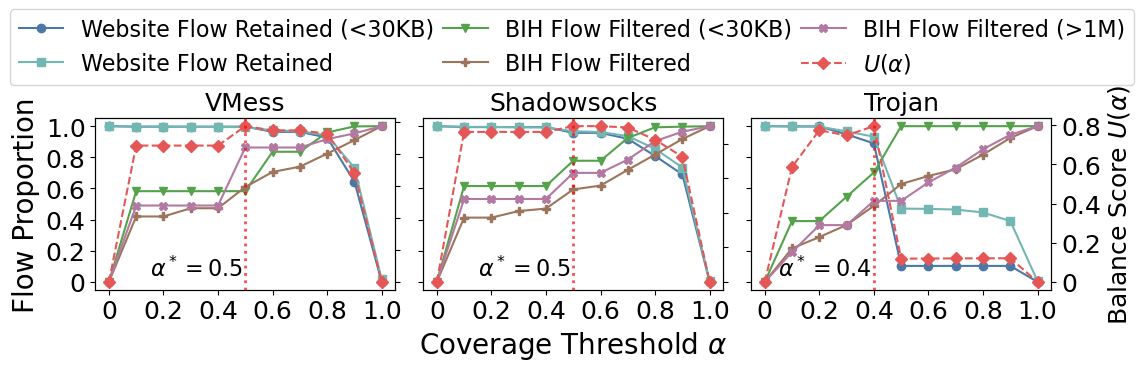

In [21]:
# After collecting the statistics, draw a 1x3 plot for the arrays.
import matplotlib.pyplot as plt

coverage_range = [i/10 for i in range(11)]
array_dicts = [
    website_flow_small_remaining,
    website_flow_remaining,
    BIH_flow_small_filtered,
    BIH_flow_filtered,
    BIH_flow_large_filtered,
]
utility_dict = utility

array_labels = [
    r"Website Flow Retained (<30KB)",
    "Website Flow Retained",
    r"BIH Flow Filtered (<30KB)",
    "BIH Flow Filtered",
    r"BIH Flow Filtered (>1M)",
]
marker_dict = ['o', 's', 'v', 'P', 'X']
color_dict = ['#4C78A8', '#72B7B2', '#54A24B', '#9D755D', '#B279A2']
utility_marker = 'D'

protocols_display = ['VMess', 'Shadowsocks', 'Trojan']

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3), sharey=True)
utility_axes = [None] * 3

lines = []
labels = []
utility_lines = []
utility_labels = []

for idx, protocol in enumerate(protocols_display):
    ax = axes[idx]
    protocol_key = protocol.lower()
    these_lines = []
    # Plot all arrays except Utility
    for arr_idx, array in enumerate(array_dicts):
        line, = ax.plot(
            coverage_range,
            array[protocol_key],
            marker=marker_dict[arr_idx],
            label=array_labels[arr_idx],
            color=color_dict[arr_idx]
        )
        # Only populate shared legend lines/labels once
        if idx == 0:
            if arr_idx < len(lines):
                continue
            lines.append(line)
            labels.append(array_labels[arr_idx])
        these_lines.append(line)

    # For every subplot, plot utility on the right y-axis
    utility_axes[idx] = ax.twinx()
    line_utility, = utility_axes[idx].plot(
        coverage_range,
        utility_dict[protocol_key],
        marker=utility_marker,
        linestyle="--",
        color='#E45756',
        label=r"$U(\alpha)$"
    )
    utility_lines.append(line_utility)
    if idx == 2:
        utility_labels.append(r"Balance score $U(\alpha)$")
    elif idx == 0:
        # Add one Utility label for the legend; only once
        utility_labels.append("Utility")
    else:
        utility_labels.append("")

    # --- Draw optimal coverage vertical line and annotation ---
    util_arr = utility_dict[protocol_key]
    util_arr_np = np.asarray(util_arr)
    max_util = np.max(util_arr_np)
    optimal_idx = np.where(util_arr_np == max_util)[0][0]  # the first max
    optimal_coverage = coverage_range[optimal_idx]

    # Draw the vertical line at optimal_coverage (across the utility axis)
    ax_vspan = utility_axes[idx].axvline(optimal_coverage, color='red', linestyle=':', linewidth=2, alpha=0.7)

    # Annotate the optimal coverage at the bottom left side of the line
    ymin, ymax = utility_axes[idx].get_ylim()
    # We want to place the text near the bottom, left side of the line
    y_annotate = ymin + 0.02 * (ymax - ymin)
    utility_axes[idx].annotate(
        rf'$\alpha^*={optimal_coverage:.1f}$',
        xy=(optimal_coverage, y_annotate),
        xytext=(-2, 4),
        textcoords='offset points',
        ha='right',
        va='bottom',
        color='black',
        fontsize=16,
    )

    ax.set_title(protocol, fontsize=18)
    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=18)
    ax.set_xlim(0, 1)
    # Set the x-axis ticks to [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    ax.set_xlim(-0.05, 1.05)
    ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_xticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1.0'])
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1.0'])
    if idx == 1:
        ax.set_xlabel(r"Coverage Threshold $\alpha$", fontsize=20)
    if idx == 0:
        ax.set_ylabel("Flow Proportion", fontsize=20)
    if idx == 2:
        utility_axes[idx].set_ylabel(r"Balance Score $U(\alpha)$", fontsize=18)
        utility_axes[idx].tick_params(axis='y', labelsize=18)
        utility_axes[idx].set_yticks([0, 0.2, 0.4, 0.6, 0.8])
        utility_axes[idx].set_yticklabels(['0', '0.2', '0.4', '0.6', '0.8'])
        # No y-label for utility axes except last one
    else:
        utility_axes[idx].set_yticklabels([])

# Build handles for the legend, using lines from left axis (first protocol), and utility from right axes (one label)
# Only use one Utility curve/label to avoid duplicate entries
all_lines = lines + [utility_lines[0]]
all_labels = labels + [r"$U(\alpha)$"]

# Place the shared legend below all the subplots
fig.legend(
    all_lines, 
    all_labels, 
    loc='upper center', 
    ncol=3, 
    bbox_to_anchor=(0.5, 1.26), 
    fontsize=16,
    columnspacing=.4
    )
plt.tight_layout()
fig.savefig("coverage.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()